In [ ]:
# 1. Create a hidden Kaggle folder and move the json file there
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# 2. Download your Forest Sentinel Dataset (305 MB)
!kaggle datasets download -d irdiansyah/forest-fire-dataset

# 3. Unzip the downloaded file into a new folder called 'dataset'
!unzip forest-fire-dataset.zip -d /content/dataset

Streaming output truncated to the last 5000 lines.
  inflating: /content/dataset/train/labels/fire-3480-31156872_png_jpg.rf.8f4e25c5ca4b9313e59d51ef95648248.txt  
  inflating: /content/dataset/train/labels/fire-3488-72996564_png_jpg.rf.529995ddf8686a47bfa09e5bd720a8e6.txt  
  inflating: /content/dataset/train/labels/fire-3488-72996564_png_jpg.rf.c5216af8845b4dcfcf8819a65506fa93.txt  
  inflating: /content/dataset/train/labels/fire-3549-0314256_png_jpg.rf.442b79b154f68ad47a57477e433fb95f.txt  
  inflating: /content/dataset/train/labels/fire-3549-0314256_png_jpg.rf.9141d10cc99d88783941a62988812851.txt  
  inflating: /content/dataset/train/labels/fire-3549-0314256_png_jpg.rf.938085dae2c0572fa430a47462b80e2d.txt  
  inflating: /content/dataset/train/labels/fire-3601-73608965_png_jpg.rf.22189f6680d1f35a017b3711ab721a47.txt  
  inflating: /content/dataset/train/labels/fire-3601-73608965_png_jpg.rf.3a47e783c4d1e773c10baa57b512d580.txt  
  inflating: /content/dataset/train/labels/fire-3601-736

In [ ]:
# 1. Install the YOLOv8 AI toolkit
!pip install ultralytics

# 2. Fix the broken paths in the data.yaml file automatically
import yaml
yaml_file = '/content/dataset/data.yaml'

with open(yaml_file, 'r') as f:
    data = yaml.safe_load(f)

# Tell YOLO exactly where the images are in Colab
data['path'] = '/content/dataset'
data['train'] = 'train/images'
data['val'] = 'valid/images'

with open(yaml_file, 'w') as f:
    yaml.dump(data, f, default_flow_style=False)

# 3. START TRAINING! (Training for 25 cycles/epochs to start)
!yolo task=detect mode=train model=yolov8n.pt data=/content/dataset/data.yaml epochs=25 imgsz=640

Ultralytics 8.4.16 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0

In [ ]:
from google.colab import drive
import shutil

# 1. This will pop up a window asking for permission to connect to your Google Drive
drive.mount('/content/drive')

# 2. This copies your trained AI brain directly into your Google Drive
source_path = '/content/runs/detect/train/weights/best.pt'
destination_path = '/content/drive/MyDrive/ForestSentinel_Brain.pt'

shutil.copy(source_path, destination_path)
print("SUCCESS! The Forest Sentinel brain is saved permanently to your Google Drive!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


FileNotFoundError: [Errno 2] No such file or directory: '/content/runs/detect/train/weights/best.pt'

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from ultralytics import YOLO
from google.colab.patches import cv2_imshow

# 1. Load your newly trained AI brain directly from your Google Drive
model = YOLO('/content/drive/MyDrive/ForestSentinel_Brain.pt')

# 2. Tell the AI to look at your uploaded picture
# (Note: If you named your picture something else, change 'fire_test.jpg' to match exactly!)
results = model('/content/fire_test.jpg')

# 3. Draw the detection boxes and show the final image right here in Colab!
image_with_boxes = results[0].plot()
cv2_imshow(image_with_boxes)

In [ ]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode
from ultralytics import YOLO
from google.colab.patches import cv2_imshow

# 1. This is the special bridge to turn on your laptop camera
def take_photo(filename='live_test.jpg', quality=0.8):
  js = Javascript('''
    async function takePhoto(quality) {
      const div = document.createElement('div');
      const capture = document.createElement('button');
      capture.textContent = 'Capture';
      div.appendChild(capture);

      const video = document.createElement('video');
      video.style.display = 'block';
      const stream = await navigator.mediaDevices.getUserMedia({video: true});

      document.body.appendChild(div);
      div.appendChild(video);
      video.srcObject = stream;
      await video.play();

      google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);
      await new Promise((resolve) => capture.onclick = resolve);

      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;
      canvas.getContext('2d').drawImage(video, 0, 0);
      stream.getVideoTracks()[0].stop();
      div.remove();
      return canvas.toDataURL('image/jpeg', quality);
    }
    ''')
  display(js)
  data = eval_js('takePhoto({})'.format(quality))
  binary = b64decode(data.split(',')[1])
  with open(filename, 'wb') as f:
    f.write(binary)
  return filename

# 2. Turn on the camera and wait for you to click 'Capture'
try:
  print("Waiting for you to take a photo... (Look for the 'Capture' button below!)")
  image_file = take_photo()

  # 3. Pass that live photo directly to the Forest Sentinel Brain
  print("Photo snapped! The AI is analyzing it right now...")
  model = YOLO('/content/drive/MyDrive/ForestSentinel_Brain.pt')
  results = model(image_file)

  # 4. Show the final result on your screen
  image_with_boxes = results[0].plot()
  cv2_imshow(image_with_boxes)

except Exception as err:
  print(str(err))

Waiting for you to take a photo... (Look for the 'Capture' button below!)


<IPython.core.display.Javascript object>

In [ ]:
!pip install ultralytics requests

Waiting for you to take a photo... (Look for the 'Capture' button!)


<IPython.core.display.Javascript object>

Photo snapped! The AI is analyzing...

image 1/1 /content/live_test.jpg: 480x640 2 fires, 7.9ms
Speed: 1.4ms preprocess, 7.9ms inference, 1.9ms postprocess per image at shape (1, 3, 480, 640)

⚠️ FIRE DETECTED! (Confidence: 36%)
Compressing data for LoRa transmission...
Compressing data for secure LoRa transmission...
✅ Packet transmitted successfully to SECURE server!



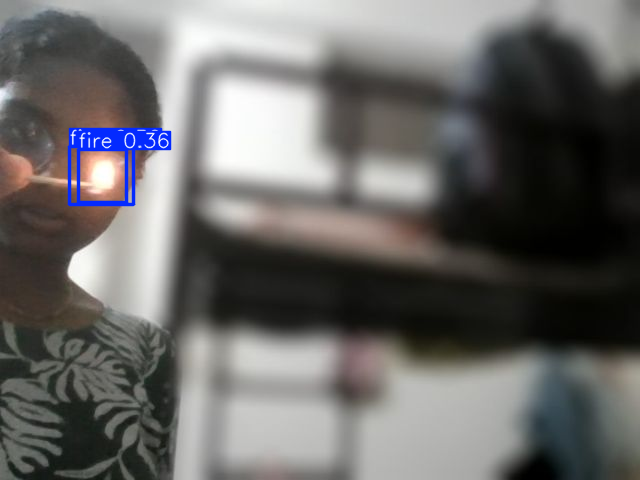

In [ ]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode
from ultralytics import YOLO
from google.colab.patches import cv2_imshow
import requests

# 1. The laptop camera bridge
def take_photo(filename='live_test.jpg', quality=0.8):
  js = Javascript('''
    async function takePhoto(quality) {
      const div = document.createElement('div');
      const capture = document.createElement('button');
      capture.textContent = 'Capture';
      div.appendChild(capture);
      const video = document.createElement('video');
      video.style.display = 'block';
      const stream = await navigator.mediaDevices.getUserMedia({video: true});
      document.body.appendChild(div);
      div.appendChild(video);
      video.srcObject = stream;
      await video.play();
      google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);
      await new Promise((resolve) => capture.onclick = resolve);
      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;
      canvas.getContext('2d').drawImage(video, 0, 0);
      stream.getVideoTracks()[0].stop();
      div.remove();
      return canvas.toDataURL('image/jpeg', quality);
    }
    ''')
  display(js)
  data = eval_js('takePhoto({})'.format(quality))
  binary = b64decode(data.split(',')[1])
  with open(filename, 'wb') as f:
    f.write(binary)
  return filename

# 2. Start the main AI process
try:
  print("Waiting for you to take a photo... (Look for the 'Capture' button!)")
  image_file = take_photo()

  print("Photo snapped! The AI is analyzing...")
  model = YOLO('/content/drive/MyDrive/ForestSentinel_Brain.pt')
  results = model(image_file,conf=0.10)

  # --- THE LORAWAN SIMULATION SYSTEM ---
  boxes = results[0].boxes
  if len(boxes) > 0: # If it detected anything
      confidence = boxes[0].conf[0].item()

      if confidence > 0.10: # If it is more than 35% sure it's a fire
          print(f"\n⚠️ FIRE DETECTED! (Confidence: {round(confidence*100)}%)")
          print("Compressing data for LoRa transmission...")

          # LoRa requires tiny payloads.
          # --- NEW SECURE TRANSMISSION LOGIC ---
          print("Compressing data for secure LoRa transmission...")

        # We only send the confidence number to keep the radio payload ultra-lightweight
          payload_number = str(round(confidence * 100))

        # ⚠️ CRITICAL FIX: Match the channel to the new Streamlit dashboard!
          requests.post("https://ntfy.sh/gnits_panel_final_v1", data=payload_number)

          print("✅ Packet transmitted successfully to SECURE server!\n")
      else:
          print("🌲 All clear. No anomalies detected.")
  # -------------------------------------

  # 3. Draw the boxes and show the final image
  image_with_boxes = results[0].plot()
  cv2_imshow(image_with_boxes)

except Exception as err:
  print(str(err))